# 1. Setup e importación de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import requests
import random
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Prince (MCA)
import prince

# Scipy
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr
from scipy.spatial.distance import cdist

# Configuración general de los gráficos y de pandas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)

# Seed unificada para que el análisis sea reproducible entre corridas.
# Fijamos también las semillas globales de numpy y random, además de pasar
# SEED como random_state en cada modelo de sklearn.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

Cargamos el df enriquecido en `06_reduccion_y_clustering.ipynb`

In [2]:
import pickle
import pandas as pd
import numpy as np

df = pd.read_pickle('../data/processed/checkpoint_post_clustering.pkl')

with open('../data/processed/extras_post_clustering.pkl', 'rb') as f:
    extras = pickle.load(f)

df_kpis            = extras['df_kpis']
gdf_barrios        = extras['gdf_barrios']
perfil_mediana     = extras['perfil_mediana']
perfil_cluster_geo = extras['perfil_cluster_geo']
SEED               = extras['SEED']

print(f'Checkpoint cargado: {len(df):,} propiedades, {df["cluster"].notna().sum():,} con cluster asignado')

Checkpoint cargado: 51,992 propiedades, 44,138 con cluster asignado


# 2. Modelos explicativos

En esta sección construimos dos modelos con objetivos distintos, pensados para responder las preguntas centrales del proyecto desde la perspectiva del inversor.

El primero busca explicar qué determina el precio por metro cuadrado en las ventas. No es un modelo predictivo en el sentido estricto (no buscamos predecir el precio de una propiedad nueva) sino uno explicativo: queremos entender qué variables mueven el precio y en qué dirección, y cuánto pesa cada una relativa al resto.

El segundo modelo clasifica la modalidad de alquiler óptima para cada perfil de propiedad: si conviene apuntar al alquiler temporario o al largo plazo. El target lo construimos a partir de los KPIs calculados en la entrega anterior: para cada barrio, la modalidad óptima es la que tiene mayor rentabilidad neta.

Para ambos modelos usamos el mismo conjunto de features, que combina variables físicas de la propiedad, los índices sintéticos construidos en la sección 4 y las variables espaciales de la sección 2. Las features con menos del 30% de cobertura se excluyen automáticamente para no distorsionar los modelos.

In [3]:
FEATURES_BASE = [
    # Físicas de la propiedad
    'm2_total', 'dormitorios', 'baños', 'ambientes',
    # Índices sintéticos (sección 4)
    'indice_lujo', 'indice_confort']


# Agregamos score_antiguedad solo si tiene buena cobertura (>50% no nulo)
if 'score_antiguedad' in df.columns and df['score_antiguedad'].notna().mean() > 0.5:
    FEATURES_BASE.append('score_antiguedad')

# Espaciales — agregamos solo las que existen en df
for col_esp in ['nivel_socioeconomico', 'dist_subte_km', 'dist_verde_km', 'dist_tren_km']:
    if col_esp in df.columns and df[col_esp].notna().mean() > 0.3:
        FEATURES_BASE.append(col_esp)

features_ok = [f for f in FEATURES_BASE if f in df.columns]
print(f'Features disponibles ({len(features_ok)}):')
for f in features_ok:
    cobertura = df[f].notna().mean() * 100
    print(f'  {f}: {cobertura:.1f}% cobertura')

# Dataset para precio (target continuo)
df_precio = df[
    (df['operacion'] == 'venta') &
    df['precio_por_m2_usd'].notna()
][features_ok + ['precio_por_m2_usd', 'barrio_oficial']].dropna()

print(f'\nRegistros para modelo de precio: {len(df_precio):,}')
if len(df_precio) < 100:
    print('Atención: muy pocos registros. Verificá que la sección 1 cargó bien el dataset.')

# Dataset para modalidad (target binario)
# La modalidad óptima es un atributo del barrio (del df_kpis),
# no de la propiedad individual. La asignamos a cada propiedad
# según su barrio, sin hacer dropna agresivo por features.

kpis_mod = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns \
           else df_kpis.copy()

# Verificamos que existen las columnas necesarias
cols_necesarias = ['rent_neta_temp_pct', 'rent_neta_lp_pct']
cols_faltantes = [c for c in cols_necesarias if c not in kpis_mod.columns]
if cols_faltantes:
    print(f'Atención: faltan columnas en df_kpis: {cols_faltantes}')
    print(f'   Columnas disponibles: {kpis_mod.columns.tolist()}')
else:
    kpis_mod['modalidad_optima'] = (
        kpis_mod['rent_neta_temp_pct'] > kpis_mod['rent_neta_lp_pct']
    ).astype(int)

    # Partimos de todas las propiedades de alquiler con features completas
    mask_alq = df['operacion'].isin(['alquiler', 'alquiler_temporal'])
    df_modal_base = df[mask_alq][features_ok + ['barrio_oficial']].dropna()

    # Mergeamos la etiqueta por barrio
    df_modal = df_modal_base.merge(
        kpis_mod[['modalidad_optima']],
        left_on='barrio_oficial', right_index=True,
        how='inner'
    )

    print(f'Registros para modelo de modalidad: {len(df_modal):,}')
    if len(df_modal) > 0:
        vc = df_modal['modalidad_optima'].value_counts()

Features disponibles (11):
  m2_total: 100.0% cobertura
  dormitorios: 100.0% cobertura
  baños: 100.0% cobertura
  ambientes: 100.0% cobertura
  indice_lujo: 100.0% cobertura
  indice_confort: 100.0% cobertura
  score_antiguedad: 100.0% cobertura
  nivel_socioeconomico: 100.0% cobertura
  dist_subte_km: 84.9% cobertura
  dist_verde_km: 84.9% cobertura
  dist_tren_km: 84.9% cobertura

Registros para modelo de precio: 24,974
Registros para modelo de modalidad: 19,097


### 2.1 ¿Qué variables explican el precio por m²? (target continuo)

Comparamos tres modelos lineales con distinto nivel de regularización:

- **OLS (sin regularización):** la regresión lineal clásica. Maximiza el ajuste al conjunto de entrenamiento sin ningún penalizador. Es el más interpretable pero el más propenso a sobreajuste si hay variables correlacionadas.
- **Ridge (L2):** agrega una penalización proporcional al cuadrado de los coeficientes. Reduce el sobreajuste distribuyendo el peso entre variables correlacionadas en lugar de concentrarlo en una sola. Ningún coeficiente llega a cero.
- **Lasso (L1):** penaliza el valor absoluto de los coeficientes, lo que puede llevarlos exactamente a cero. Funciona como selector automático de variables: las que Lasso anula son las que no aportan poder explicativo adicional dado el resto.

Los tres modelos corren dentro de un pipeline que escala las variables antes de ajustar, lo que hace que los coeficientes sean comparables entre sí (están en unidades de desvíos estándar, no en las unidades originales de cada variable). Evaluamos con R² y MAE en el conjunto de test, y con validación cruzada de 5 folds para tener una estimación más robusta del poder de generalización.

In [4]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

assert len(df_precio) >= 50, \
    f'df_precio tiene solo {len(df_precio)} filas. Revisá la preparación de datos.'

X_p = df_precio[features_ok]
y_p = df_precio['precio_por_m2_usd']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=SEED
)
print(f'Train: {len(X_train_p):,} | Test: {len(X_test_p):,}')

modelos_precio = {
    'OLS (sin regularización)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10, random_state=SEED))
    ]),
    'Lasso (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=1.0, max_iter=5000, random_state=SEED))
    ]),
}

resultados_precio = {}
for nombre, pipe in modelos_precio.items():
    pipe.fit(X_train_p, y_train_p)
    y_pred = pipe.predict(X_test_p)
    cv_r2  = cross_val_score(pipe, X_p, y_p, cv=5, scoring='r2').mean()
    resultados_precio[nombre] = {
        'R2 test':     round(r2_score(y_test_p, y_pred), 3),
        'MAE test':    round(mean_absolute_error(y_test_p, y_pred), 1),
        'R2 CV 5-fold': round(cv_r2, 3),
    }
    print(f'{nombre}: R2 test = {resultados_precio[nombre]["R2 test"]}, '
          f'MAE = {resultados_precio[nombre]["MAE test"]} USD/m2')

df_res_precio = pd.DataFrame(resultados_precio).T
print('\nTabla comparativa de los tres modelos:')
print(df_res_precio.to_string())

Train: 19,979 | Test: 4,995
OLS (sin regularización): R2 test = 0.67, MAE = 482.5 USD/m2
Ridge (L2): R2 test = 0.67, MAE = 482.5 USD/m2
Lasso (L1): R2 test = 0.67, MAE = 482.2 USD/m2

Tabla comparativa de los tres modelos:
                          R2 test  MAE test  R2 CV 5-fold
OLS (sin regularización)    0.670   482.500         0.650
Ridge (L2)                  0.670   482.500         0.650
Lasso (L1)                  0.670   482.200         0.650


Lasso presenta una mejora marginal en MAE, pero los tres modelos muestran desempeño prácticamente equivalente. Esto indica que, para este conjunto de variables, la regularización no mejora de manera significativa la capacidad predictiva frente a OLS.

#### Lectura de los coeficientes estandarizados

Como los tres modelos escalan las variables antes de ajustar, los coeficientes son directamente comparables: un coeficiente de valor X significa que, manteniendo el resto de las variables en su valor promedio, un aumento de un desvío estándar en esa variable se asocia con un cambio de X dólares en el precio por metro cuadrado.

El signo indica la dirección del efecto: coeficiente positivo significa que la variable sube el precio, negativo que lo baja. Las variables con coeficiente cercano a cero (o que Lasso llevó exactamente a cero) no tienen efecto discernible sobre el precio una vez que se controla por el resto.

Coeficientes OLS estandarizados
Un coeficiente de X significa que, manteniendo el resto constante,
esa variable mueve el precio por metro cuadrado en X dólares al variar un desvío estándar.

score_antiguedad       -673.060
nivel_socioeconomico    281.220
m2_total                184.230
indice_lujo             174.250
baños                   143.550
indice_confort          -80.650
dist_verde_km           -63.100
ambientes               -62.720
dist_tren_km             61.130
dist_subte_km           -28.750
dormitorios               5.470


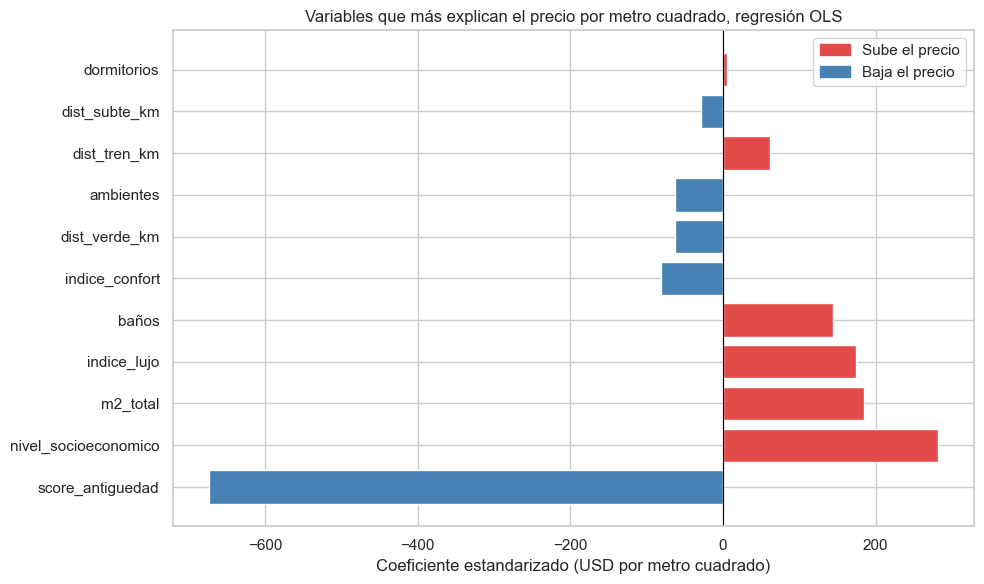

In [5]:
# Coeficientes del mejor modelo lineal.
# Usamos OLS para máxima interpretabilidad de los coeficientes.
pipe_ols = modelos_precio['OLS (sin regularización)']
coefs = pd.Series(
    pipe_ols.named_steps['model'].coef_,
    index=features_ok
).sort_values(key=abs, ascending=False)

print('Coeficientes OLS estandarizados')
print('Un coeficiente de X significa que, manteniendo el resto constante,')
print('esa variable mueve el precio por metro cuadrado en X dólares al variar un desvío estándar.\n')
print(coefs.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores_coef = ['#E24B4A' if c > 0 else 'steelblue' for c in coefs]
ax.barh(coefs.index, coefs.values, color=colores_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente estandarizado (USD por metro cuadrado)')
ax.set_title('Variables que más explican el precio por metro cuadrado, regresión OLS')
patch_pos = mpatches.Patch(color='#E24B4A', label='Sube el precio')
patch_neg = mpatches.Patch(color='steelblue', label='Baja el precio')
ax.legend(handles=[patch_pos, patch_neg])
plt.tight_layout()
plt.show()

Según la regresión lineal, las variables que más impactan al precio son el score_antiguedad (con relación fuertemente negativa), el nivel socioeconómico del barrio, la cantidad de metros cuadrados totales, el índice de lujo y la cantidad de baños de la propiedad. Dos de estas variables están relacionadas con la superficie de la propiedad, mientras que score antiguedad, nivel socioeconomico e indice de lujo se relacionan con el estado general y percepción del status de la propiedad.

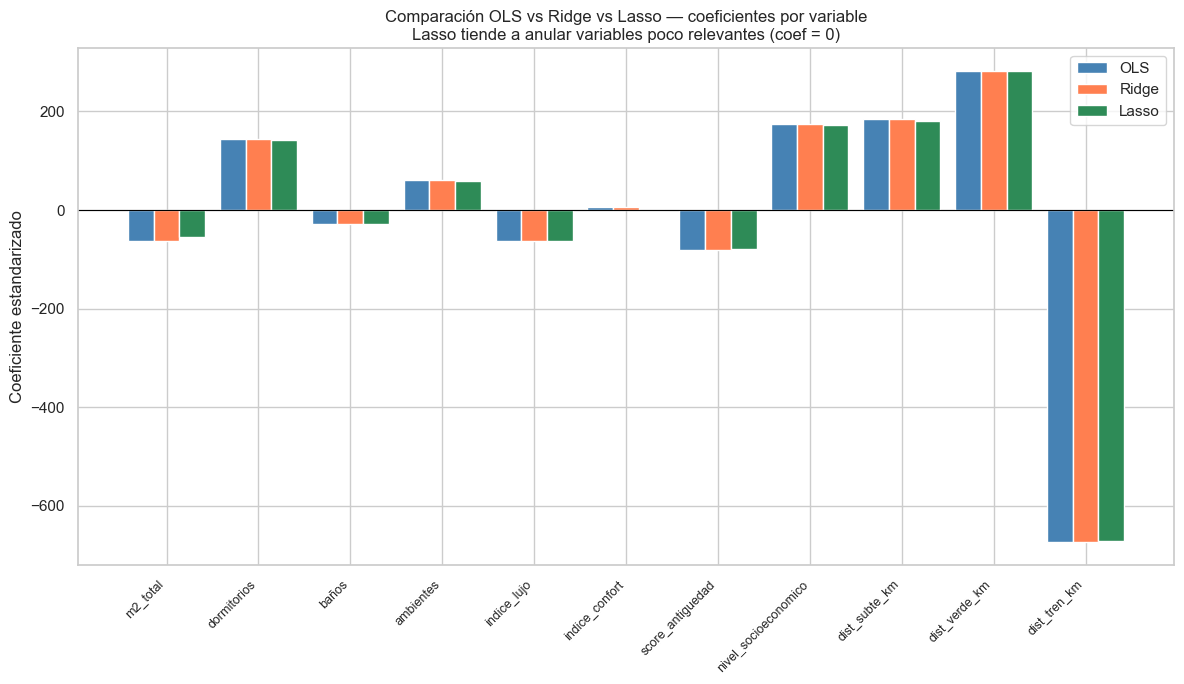


Variables anuladas por Lasso (coef = 0): ['dormitorios']
→ Estas variables no aportan poder explicativo adicional al precio/m².


In [6]:
# Comparación visual OLS vs Lasso vs Ridge
# Muestra qué features Lasso "apaga" (coef → 0)
coefs_lasso = pd.Series(
    modelos_precio['Lasso (L1)'].named_steps['model'].coef_,
    index=features_ok
)
coefs_ridge = pd.Series(
    modelos_precio['Ridge (L2)'].named_steps['model'].coef_,
    index=features_ok
)

df_coefs = pd.DataFrame({
    'OLS':   coefs,
    'Ridge': coefs_ridge,
    'Lasso': coefs_lasso,
})

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(features_ok))
width = 0.28
ax.bar(x - width, df_coefs['OLS'],   width, label='OLS',   color='steelblue', edgecolor='white')
ax.bar(x,         df_coefs['Ridge'], width, label='Ridge',  color='coral',     edgecolor='white')
ax.bar(x + width, df_coefs['Lasso'], width, label='Lasso',  color='seagreen',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(features_ok, rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coeficiente estandarizado')
ax.set_title('Comparación OLS vs Ridge vs Lasso — coeficientes por variable\n'
             'Lasso tiende a anular variables poco relevantes (coef = 0)')
ax.legend()
plt.tight_layout()
plt.show()

lasso_nulos = coefs_lasso[coefs_lasso == 0].index.tolist()
print(f'\nVariables anuladas por Lasso (coef = 0): {lasso_nulos if lasso_nulos else "ninguna"}')
print('→ Estas variables no aportan poder explicativo adicional al precio/m².')

#### Árbol de decisión como complemento interpretativo

Los modelos lineales asumen que el efecto de cada variable es constante a lo largo de todo su rango, lo que a veces es una simplificación fuerte. El árbol de decisión complementa ese análisis particionando el espacio de features en segmentos y estimando el precio promedio de cada uno.

Con una profundidad máxima de 4 niveles y al menos 50 propiedades por hoja, el árbol produce reglas que el inversor puede leer directamente: "si el nivel socioeconómico del barrio es alto y la superficie supera X m², el precio mediano es Y USD/m²". Esa lectura en segmentos es más natural para tomar una decisión de inversión que interpretar un coeficiente.

Limitación importante: el árbol de scikit-learn no tiene poda por costo-complejidad activada por defecto, así que la profundidad máxima que fijamos es el principal control contra el sobreajuste. Un R² notablemente más alto en entrenamiento que en test sería señal de que el árbol memorizó el dataset en lugar de generalizar.

Árbol de decisión para el precio por metro cuadrado
R2 test:  0.713
MAE test: 446.5 USD/m2


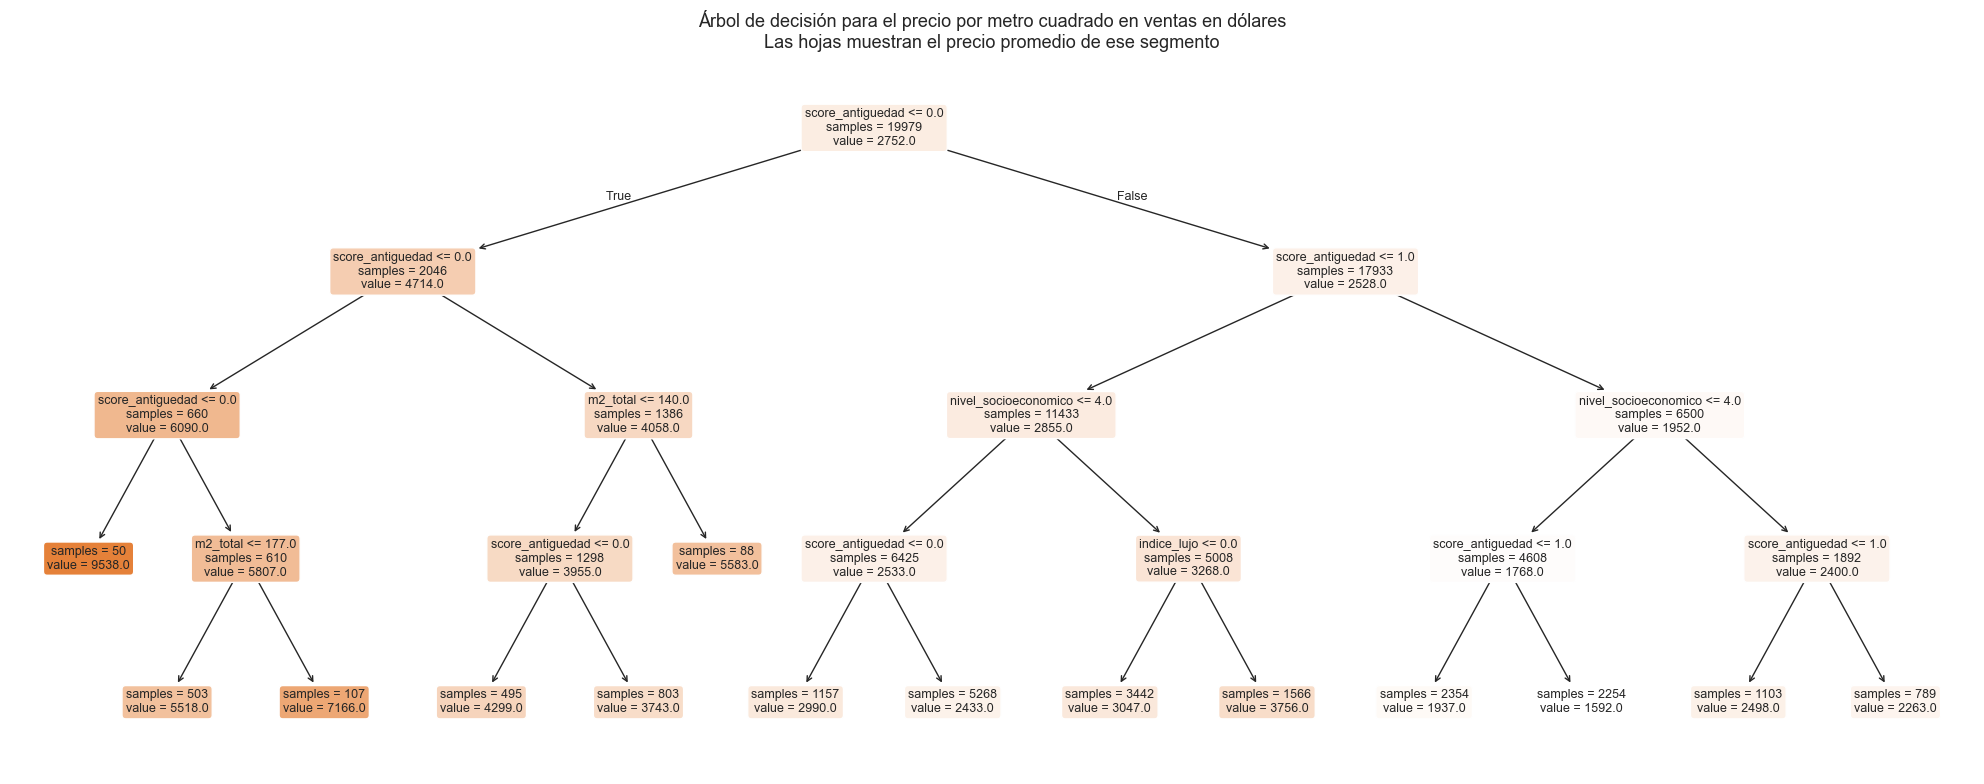

In [7]:
# Árbol de decisión para precio.
# Complementa la regresión mostrando reglas simples que el inversor puede leer.

arbol_precio = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=50,
    random_state=SEED
)
arbol_precio.fit(X_train_p, y_train_p)

y_pred_arbol = arbol_precio.predict(X_test_p)
print('Árbol de decisión para el precio por metro cuadrado')
print(f'R2 test:  {r2_score(y_test_p, y_pred_arbol):.3f}')
print(f'MAE test: {mean_absolute_error(y_test_p, y_pred_arbol):.1f} USD/m2')

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    arbol_precio,
    feature_names=features_ok,
    filled=True, rounded=True,
    fontsize=9, ax=ax,
    impurity=False, precision=0
)
ax.set_title('Árbol de decisión para el precio por metro cuadrado en ventas en dólares\n'
             'Las hojas muestran el precio promedio de ese segmento', fontsize=13)
plt.tight_layout()
plt.show()

La lectura de este árbol es más sencilla que la regresión lineal. En primer lugar, se ve que el árbol determina las primeras decisiones a base del score de antiguedad, seguido por algunas variables como nivel socioeconomico, los metros cuadrados totales y el indice de lujo. Son variables que para la regresión lineal también resultaban importantes.

### 2.2 ¿Qué tipo de alquiler conviene? (target binario)





La pregunta de si conviene el alquiler temporario o el largo plazo no tiene una respuesta universal: depende de las características de la propiedad y del barrio donde está. Para modelarla construimos un target binario a nivel barrio: `1` si la rentabilidad neta temporaria supera a la de largo plazo en ese barrio, `0` en caso contrario. Luego asignamos esa etiqueta a cada propiedad según su barrio, lo que nos da un dataset con el perfil físico y espacial de cada inmueble junto con la modalidad que más rindió históricamente en su zona.

Comparamos dos modelos:

- **Regresión logística:** estima la probabilidad de que la modalidad óptima sea temporaria como función lineal de las features (en escala logit). Usamos `class_weight='balanced'` para compensar un posible desbalance entre clases. Los coeficientes se expresan como odds ratios, que tienen una lectura directa: un OR mayor a 1 significa que esa variable favorece el alquiler temporario; menor a 1, que favorece el largo plazo.
- **Árbol de clasificación:** igual que en el modelo de precio, ofrece reglas explícitas por segmento. Es útil para comunicarle al inversor perfiles concretos ("propiedades con Índice de Lujo alto y cerca del subte: temporario").

El split de entrenamiento/test es estratificado para preservar la proporción de clases en ambos conjuntos.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

# Verificación de que df_modal tiene datos y al menos dos clases
assert len(df_modal) >= 20, \
    f'df_modal tiene solo {len(df_modal)} filas. Revisá la preparación de datos.'

n_clases = df_modal['modalidad_optima'].nunique()
assert n_clases == 2, (
    f'modalidad_optima tiene solo {n_clases} valores únicos: '
    f'{df_modal["modalidad_optima"].unique()}. '
    f'No es posible un modelo binario. Revisá los KPIs en df_kpis.'
)

X_m = df_modal[features_ok]
y_m = df_modal['modalidad_optima']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=SEED, stratify=y_m
)
print(f'Train: {len(X_train_m):,} | Test: {len(X_test_m):,}')
print(f'Clases en test: largo plazo {(y_test_m==0).sum()}, temporario {(y_test_m==1).sum()}')

# Regresión logística
pipe_logit = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])
pipe_logit.fit(X_train_m, y_train_m)
y_pred_logit  = pipe_logit.predict(X_test_m)
y_prob_logit  = pipe_logit.predict_proba(X_test_m)[:, 1]

print('\nRegresión logística: temporario contra largo plazo')
print(classification_report(y_test_m, y_pred_logit,
      target_names=['Largo plazo', 'Temporario']))
print(f'AUC-ROC: {roc_auc_score(y_test_m, y_prob_logit):.3f}')

Train: 15,277 | Test: 3,820
Clases en test: largo plazo 3792, temporario 28

Regresión logística: temporario contra largo plazo
              precision    recall  f1-score   support

 Largo plazo       1.00      0.97      0.99      3792
  Temporario       0.20      1.00      0.34        28

    accuracy                           0.97      3820
   macro avg       0.60      0.99      0.66      3820
weighted avg       0.99      0.97      0.98      3820

AUC-ROC: 0.993


El conjunto de test está fuertemente desbalanceado: hay muchos más casos donde conviene largo plazo que casos donde conviene temporario. Por eso no alcanza con mirar la accuracy general, ya que un modelo podría acertar mucho simplemente prediciendo casi siempre la clase mayoritaria.

En este caso, la regresión logística logra un recall muy alto para la clase temporario, es decir, identifica casi todos los casos donde temporario era la modalidad óptima. Sin embargo, la precision es baja, lo que indica que también clasifica como temporarios algunos casos que en realidad correspondían a largo plazo. Esto se ve reflejado también en el f1-score bajo (0.34) del alquiler temporario. Para un inversor, esto puede ser útil como filtro inicial, pero no debería tomarse como decisión automática. Requiere de mayor análisis utilizando otras metodologías.

Odds ratios estandarizados de la regresión logística
OR mayor a 1: la variable favorece elegir alquiler temporario
OR menor a 1: la variable favorece largo plazo

dist_subte_km          1.522
baños                  1.329
dormitorios            1.141
indice_lujo            1.074
ambientes              1.056
dist_verde_km          0.845
m2_total               0.733
indice_confort         0.600
score_antiguedad       0.528
dist_tren_km           0.168
nivel_socioeconomico   0.003


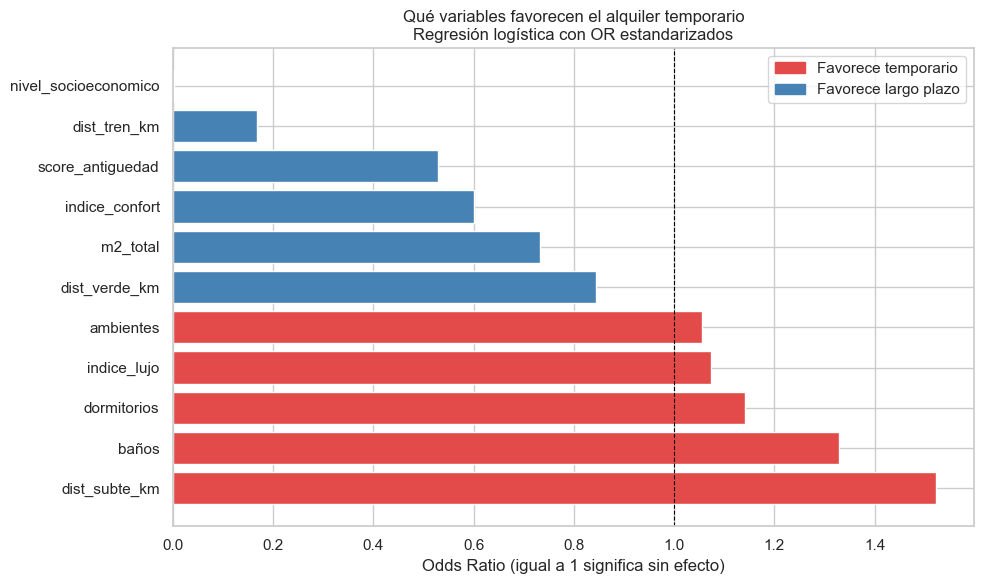

In [9]:
# Odds ratios de la regresión logística.
# OR mayor a 1 significa que la variable favorece el alquiler temporario.
# OR menor a 1 significa que favorece el largo plazo.

coef_logit = pd.Series(
    pipe_logit.named_steps['model'].coef_[0],
    index=features_ok
)
odds_ratios = np.exp(coef_logit).sort_values(ascending=False)

print('Odds ratios estandarizados de la regresión logística')
print('OR mayor a 1: la variable favorece elegir alquiler temporario')
print('OR menor a 1: la variable favorece largo plazo\n')
print(odds_ratios.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores_or = ['#E24B4A' if v > 1 else 'steelblue' for v in odds_ratios]
ax.barh(odds_ratios.index, odds_ratios.values, color=colores_or, edgecolor='white')
ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Odds Ratio (igual a 1 significa sin efecto)')
ax.set_title('Qué variables favorecen el alquiler temporario\nRegresión logística con OR estandarizados')
patch_temp = mpatches.Patch(color='#E24B4A', label='Favorece temporario')
patch_lp   = mpatches.Patch(color='steelblue', label='Favorece largo plazo')
ax.legend(handles=[patch_temp, patch_lp])
plt.tight_layout()
plt.show()

Para un alquiler temporario, salta una variable poco visible en análisis previos: la distancia al subte. Esto tiene lógica ya que las personas que suelen buscar un alquiler temporario están en la ciudad por una corta cantidad de tiempo y buscan estar en lugares con buenas capacidades de transporte. 

Árbol de clasificación: modalidad de alquiler
              precision    recall  f1-score   support

 Largo plazo       1.00      0.97      0.99      3792
  Temporario       0.21      0.96      0.35        28

    accuracy                           0.97      3820
   macro avg       0.61      0.97      0.67      3820
weighted avg       0.99      0.97      0.98      3820



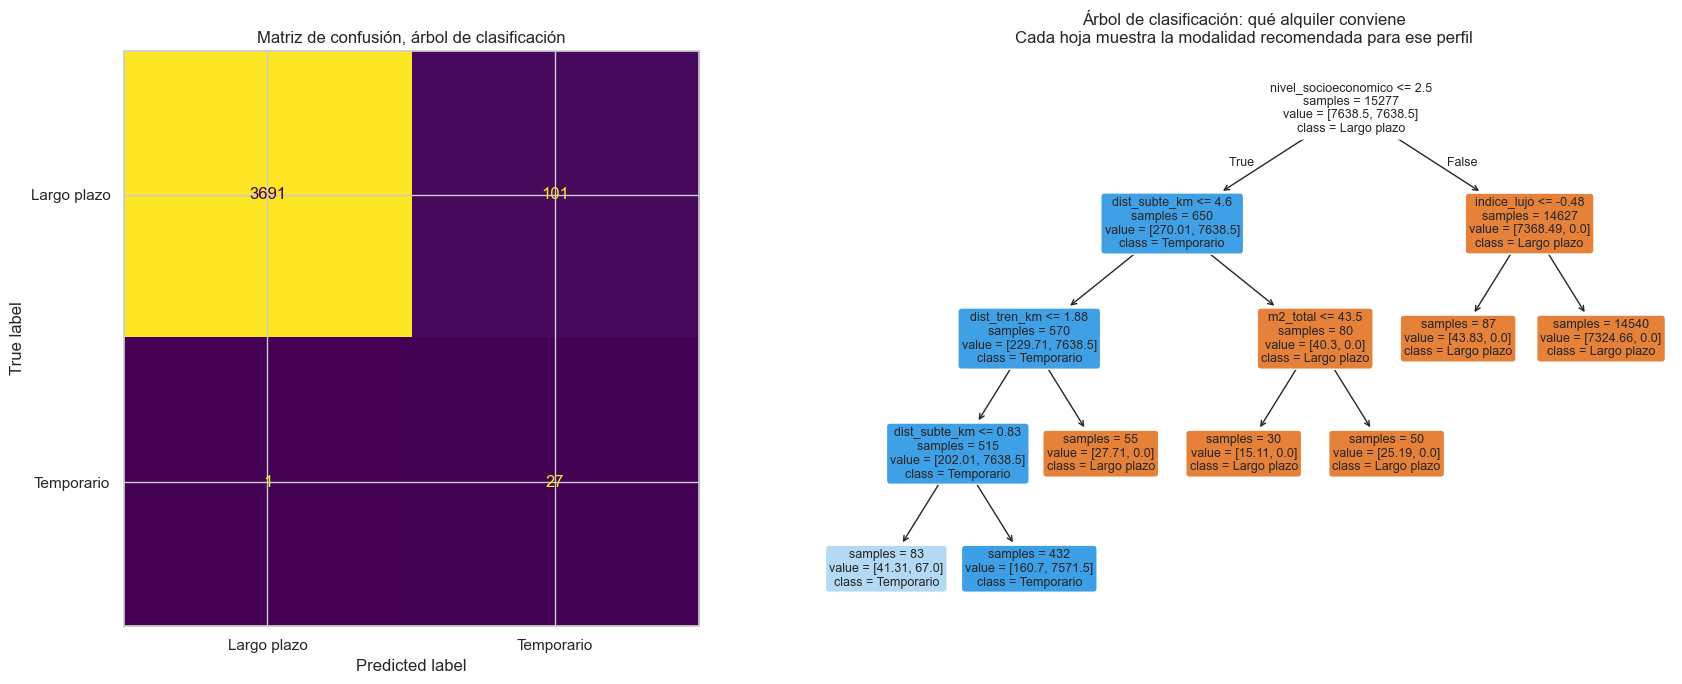

In [10]:
# Árbol de clasificación
arbol_modal = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=SEED,
    class_weight='balanced'
)
arbol_modal.fit(X_train_m, y_train_m)
y_pred_arbol_m = arbol_modal.predict(X_test_m)

print('Árbol de clasificación: modalidad de alquiler')
print(classification_report(y_test_m, y_pred_arbol_m,
      target_names=['Largo plazo', 'Temporario']))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión
cm = confusion_matrix(y_test_m, y_pred_arbol_m)
ConfusionMatrixDisplay(cm, display_labels=['Largo plazo', 'Temporario']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión, árbol de clasificación')

# Árbol
plot_tree(
    arbol_modal,
    feature_names=features_ok,
    class_names=['Largo plazo', 'Temporario'],
    filled=True, rounded=True,
    fontsize=9, ax=axes[1],
    impurity=False, precision=2
)
axes[1].set_title('Árbol de clasificación: qué alquiler conviene\n'
                  'Cada hoja muestra la modalidad recomendada para ese perfil')
plt.tight_layout()
plt.show()

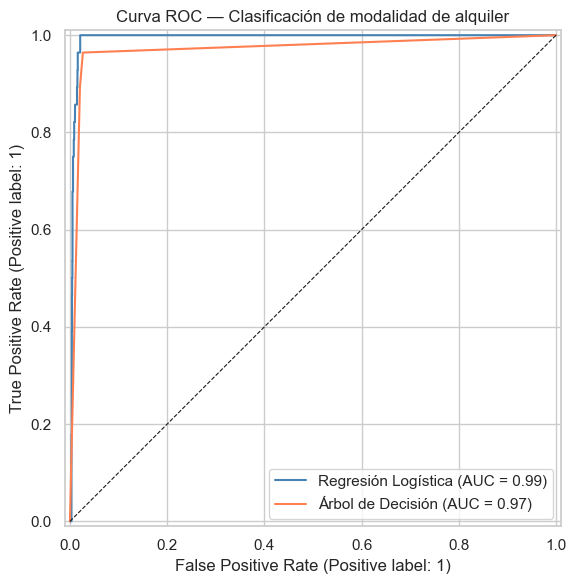

In [11]:
# Curva ROC: logística vs árbol
y_prob_arbol_m = arbol_modal.predict_proba(X_test_m)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_m, y_prob_logit,
    name='Regresión Logística', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test_m, y_prob_arbol_m,
    name='Árbol de Decisión', ax=ax, color='coral')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('Curva ROC — Clasificación de modalidad de alquiler')
plt.tight_layout()
plt.show()

#### Lectura conjunta de los modelos de modalidad

Las curvas ROC muestran una muy alta capacidad de separación entre ambas clases. La regresión logística alcanza un AUC cercano a 0.99 y el árbol de decisión un AUC cercano a 0.97, lo que indica que ambos modelos ordenan muy bien los casos según su probabilidad estimada de pertenecer a la clase temporario.

Sin embargo, estos resultados deben interpretarse con cautela. El target de modalidad óptima fue construido a nivel barrio y luego asignado a cada propiedad dentro de ese barrio. Por eso, el modelo puede estar aprendiendo patrones espaciales o socioeconómicos propios de los barrios, más que diferencias estrictamente individuales entre propiedades. Además, la clase temporario es muy minoritaria, por lo que métricas como AUC y accuracy pueden dar una impresión demasiado optimista.

En consecuencia, las curvas ROC sugieren que los modelos discriminan bien dentro de este diseño de datos, pero no prueban necesariamente que el modelo generalice con la misma calidad a barrios nuevos o a propiedades individuales fuera de la muestra.


### 2.3 Importancia de variables y análisis de sensibilidad


Los coeficientes de la regresión OLS son una primera aproximación a la importancia de cada variable, pero tienen un problema: cuando las features están correlacionadas entre sí, el modelo distribuye el peso de forma arbitraria entre ellas y los coeficientes individuales se vuelven poco confiables.

La **permutation importance** resuelve eso de otra manera: en lugar de mirar los coeficientes, aleatoriza una variable a la vez en el conjunto de test y mide cuánto cae el R². Si aleatorizar una variable no cambia el R², esa variable no era importante para el modelo. Si lo cae mucho, era clave. Las barras de error en el gráfico reflejan la variabilidad entre las 20 repeticiones del proceso de aleatorización.

El **análisis de sensibilidad** complementa la importancia mostrando la dirección y la forma del efecto. Para cada variable, recorremos su rango del percentil 5 al 95 fijando el resto en su mediana, y vemos cómo cambia el precio predicho. Una curva lineal y empinada indica un efecto fuerte y constante; una curva plana indica poco efecto; una curva no lineal indicaría que el efecto cambia a lo largo del rango (lo cual en un modelo lineal no debería aparecer, pero puede verse si hay interacciones implícitas en el set de entrenamiento).

Permutation Importance sobre el modelo OLS de precio
Caída de R2 promedio al aleatorizar cada variable (20 repeticiones):
             feature  importancia_media  importancia_std
    score_antiguedad              0.684            0.011
nivel_socioeconomico              0.123            0.005
            m2_total              0.057            0.003
         indice_lujo              0.049            0.003
               baños              0.033            0.002
      indice_confort              0.009            0.001
        dist_tren_km              0.006            0.001
       dist_verde_km              0.005            0.001
           ambientes              0.004            0.001
       dist_subte_km              0.001            0.001
         dormitorios              0.000            0.000


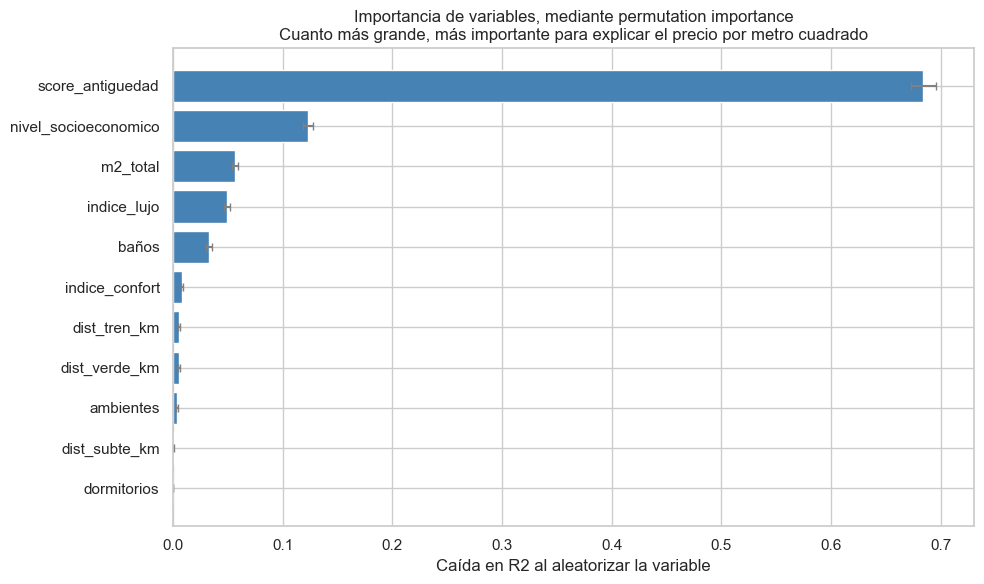

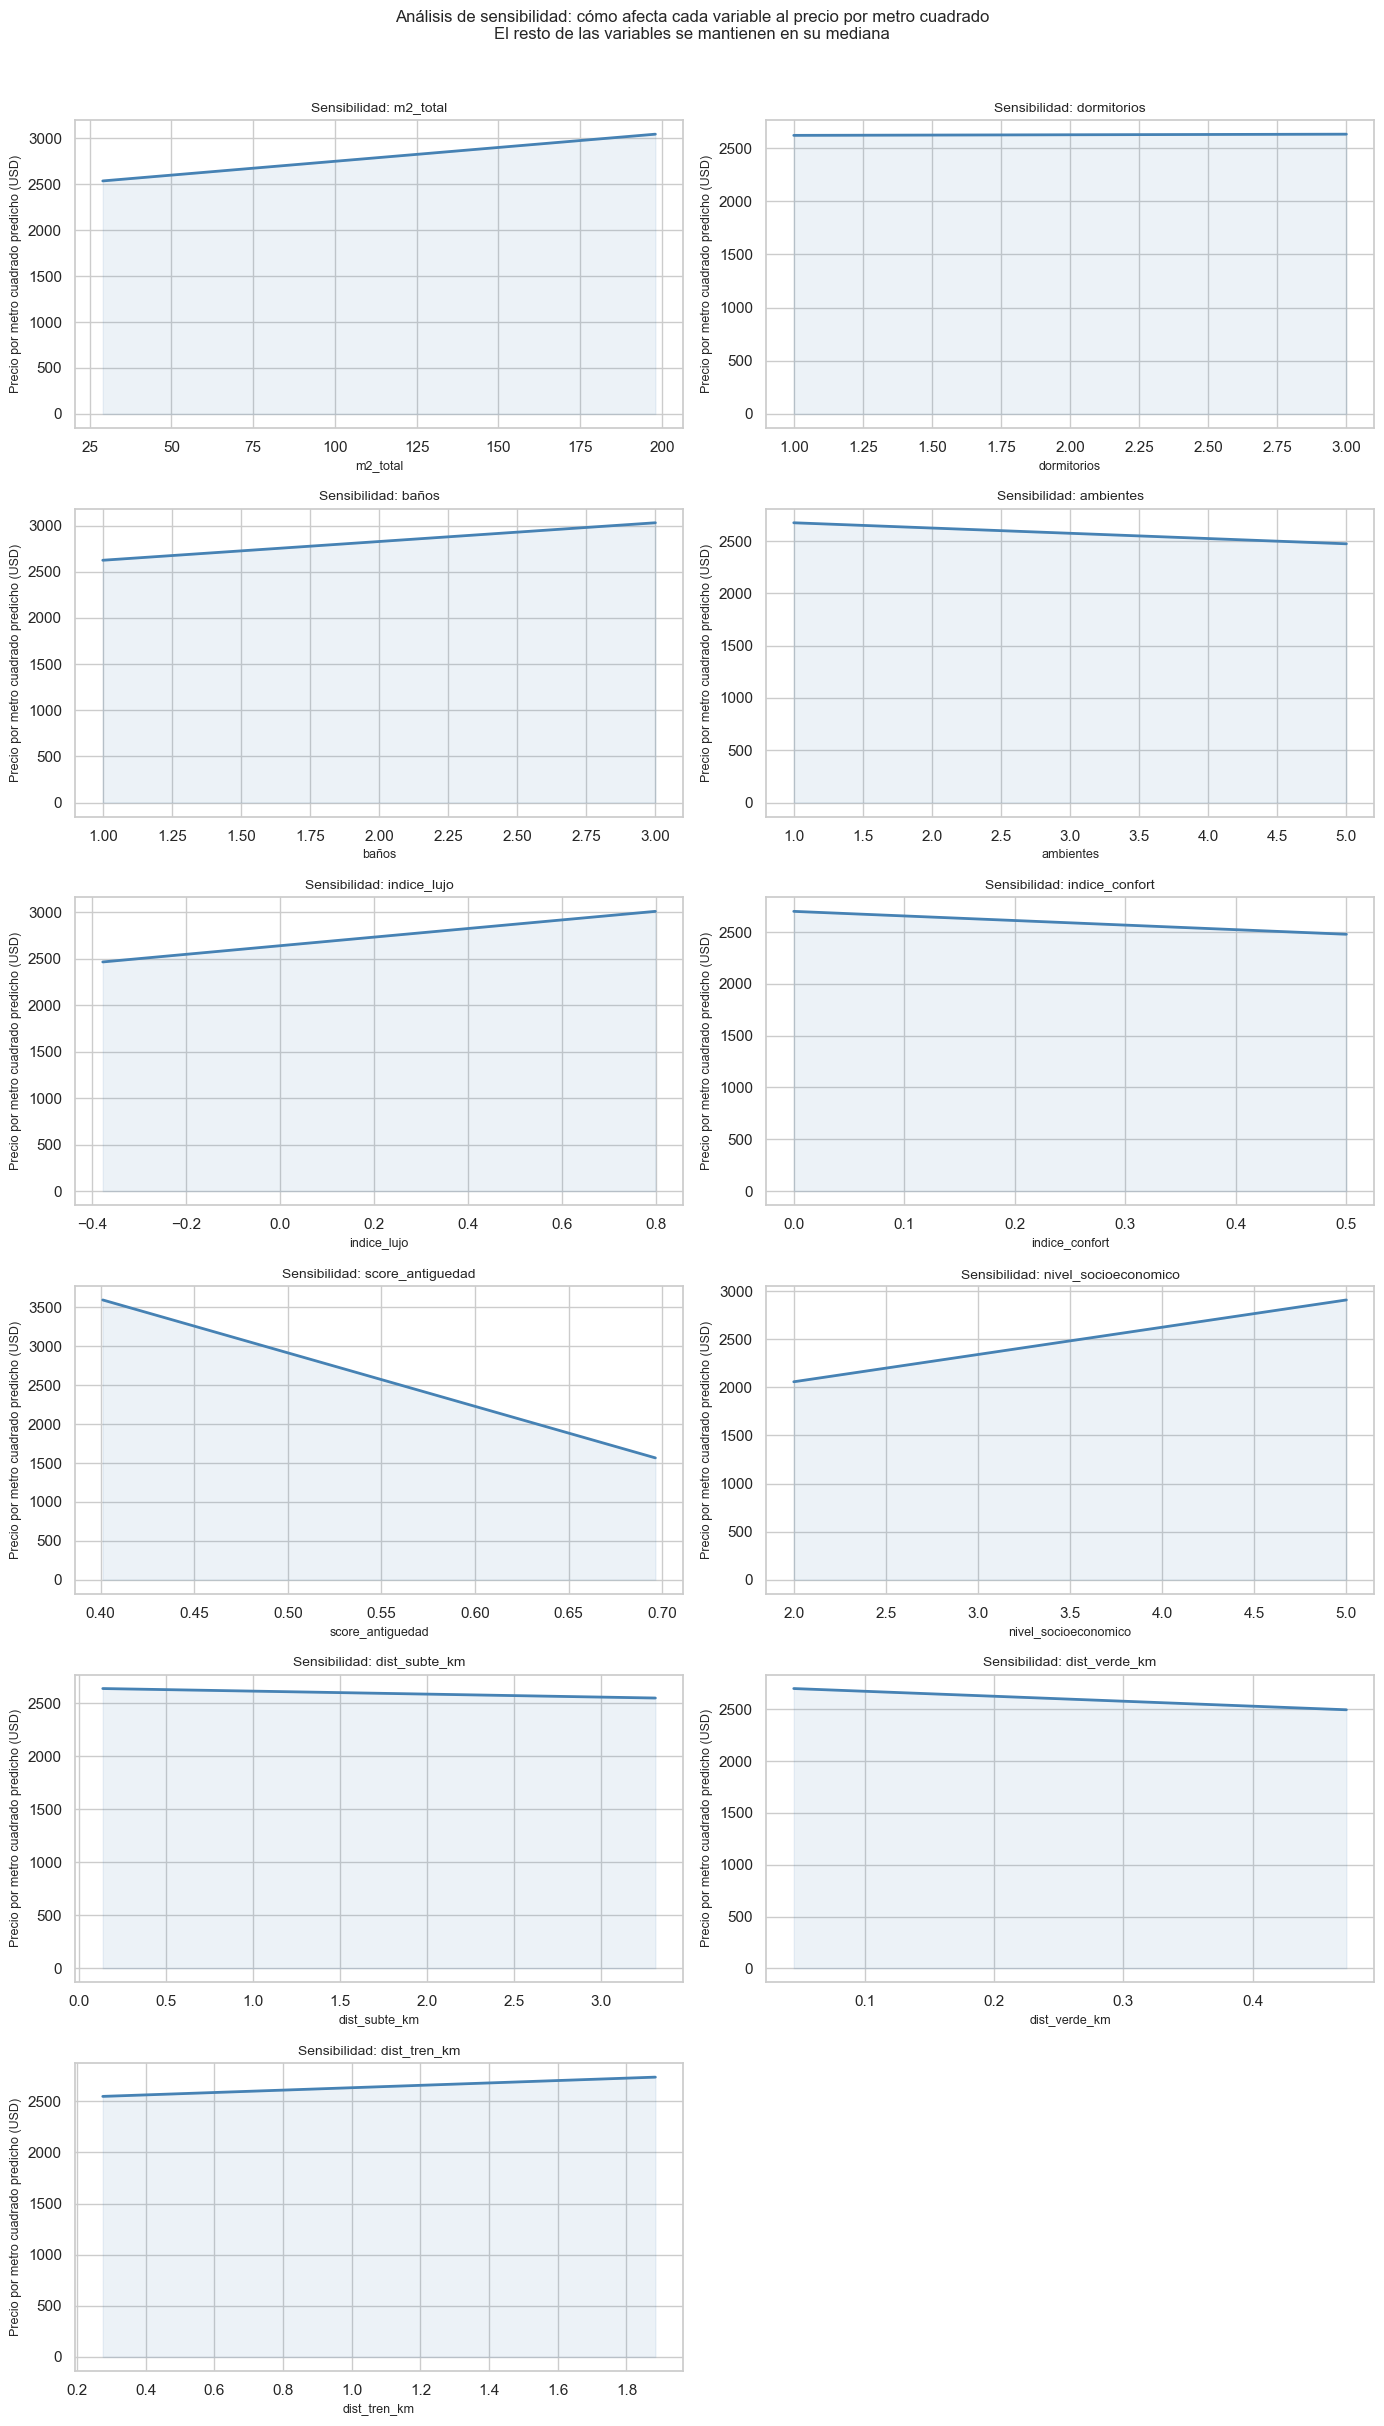

In [12]:
# Permutation Importance.
# Mide cuánto cae el R2 si aleatorizamos cada variable por separado.
# Es más confiable que leer los coeficientes directamente.

result_pi = permutation_importance(
    pipe_ols, X_test_p, y_test_p,
    n_repeats=20, random_state=SEED, scoring='r2'
)

importancias_pi = pd.DataFrame({
    'feature':           features_ok,
    'importancia_media': result_pi.importances_mean,
    'importancia_std':   result_pi.importances_std,
}).sort_values('importancia_media', ascending=False).reset_index(drop=True)

print('Permutation Importance sobre el modelo OLS de precio')
print('Caída de R2 promedio al aleatorizar cada variable (20 repeticiones):')
print(importancias_pi.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importancias_pi['feature'][::-1],
    importancias_pi['importancia_media'][::-1],
    xerr=importancias_pi['importancia_std'][::-1],
    color='steelblue', edgecolor='white', ecolor='gray', capsize=3
)
ax.set_xlabel('Caída en R2 al aleatorizar la variable')
ax.set_title('Importancia de variables, mediante permutation importance\nCuanto más grande, más importante para explicar el precio por metro cuadrado')
plt.tight_layout()
plt.show()

# Análisis de sensibilidad por variable continua.
# Para cada feature, mostramos cómo cambia el precio predicho al recorrer
# su rango entre el percentil 5 y el 95, manteniendo el resto fijo en su mediana.
fig, axes = plt.subplots(
    nrows=(len(features_ok) + 1) // 2, ncols=2,
    figsize=(14, 4 * ((len(features_ok) + 1) // 2))
)
axes = axes.flatten()

medianas_ref = X_test_p.median()

for i, feat in enumerate(features_ok):
    rango = np.linspace(
        df_precio[feat].quantile(0.05),
        df_precio[feat].quantile(0.95),
        50
    )
    predicciones = []
    for val in rango:
        X_tmp = pd.DataFrame([medianas_ref] * 50, columns=features_ok)
        X_tmp[feat] = val
        predicciones.append(pipe_ols.predict(X_tmp).mean())

    axes[i].plot(rango, predicciones, color='steelblue', linewidth=2)
    axes[i].fill_between(rango, predicciones, alpha=0.1, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Precio por metro cuadrado predicho (USD)', fontsize=9)
    axes[i].set_title(f'Sensibilidad: {feat}', fontsize=10)

# Ocultamos los subplots vacíos si la cantidad de features es impar
for j in range(len(features_ok), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Análisis de sensibilidad: cómo afecta cada variable al precio por metro cuadrado\nEl resto de las variables se mantienen en su mediana', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

La importancia medida a base de permutación y de sensibilidad tuvo conclusiones similares a la regresión lineal, remarcando la importancia de el score antiguedad, nivel socioeconomico, m2 totales, indice lujo y cantidad de baños en relacion al precio. 

Por ende, podemos señalar que es altamente recomendable para un inversor el analizar los años de la propiedad que está considerando analizar. 

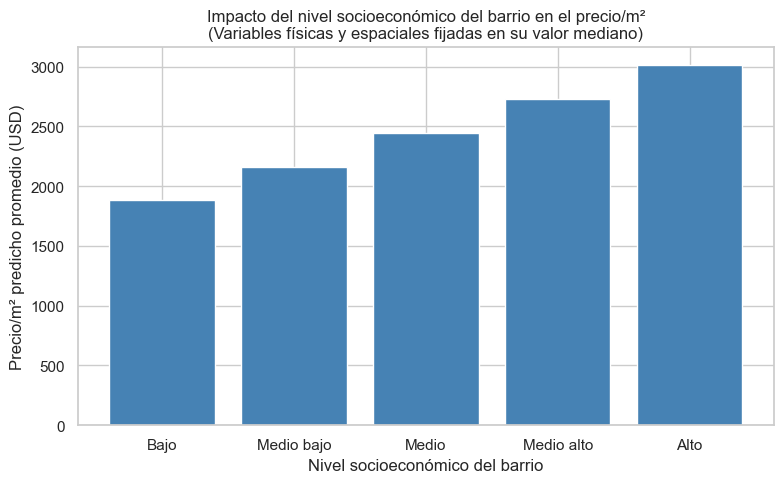

In [13]:
# Sensibilidad al nivel socioeconómico
if 'nivel_socioeconomico' in features_ok:
    niveles = sorted(df_precio['nivel_socioeconomico'].dropna().unique())
    precios_nse = []
    for nse in niveles:
        X_tmp = X_test_p.copy()
        X_tmp['nivel_socioeconomico'] = nse
        precios_nse.append(pipe_ols.predict(X_tmp).mean())

    fig, ax = plt.subplots(figsize=(8, 5))
    etiquetas_nse = {1: 'Bajo', 2: 'Medio bajo', 3: 'Medio',
                     4: 'Medio alto', 5: 'Alto'}
    ax.bar(
        [etiquetas_nse.get(int(n), str(n)) for n in niveles],
        precios_nse,
        color='steelblue', edgecolor='white'
    )
    ax.set_xlabel('Nivel socioeconómico del barrio')
    ax.set_ylabel('Precio/m² predicho promedio (USD)')
    ax.set_title('Impacto del nivel socioeconómico del barrio en el precio/m²\n'
                 '(Variables físicas y espaciales fijadas en su valor mediano)')
    plt.tight_layout()
    plt.show()

El gráfico de nivel socioeconómico es un caso especial del análisis de sensibilidad: como la variable es ordinal y discreta (toma solo cinco valores enteros), tiene más sentido mostrarla como barras que como curva continua. Muestra lo siguiente: manteniendo las características físicas y espaciales de la propiedad en sus valores medianos, ¿cuánto sube el precio predicho por metro cuadrado al pasar de un barrio de nivel bajo a uno de nivel alto? La relación incremento de precio al incrementar el nivel socioeconomico es bastante clara. 

### 2.4 Recomendación integrada para el inversor principiante

En esta sección se construye una tabla final de recomendación para el inversor principiante. A diferencia de las secciones anteriores, acá no se entrena un modelo nuevo, sino que se integran los KPIs ya calculados por barrio: rentabilidad neta estimada para alquiler de largo plazo, rentabilidad neta estimada para alquiler temporario y precio mediano por metro cuadrado.

Para cada barrio se compara la rentabilidad neta temporaria contra la rentabilidad neta de largo plazo. Si la rentabilidad temporaria es mayor, la modalidad sugerida es “Temporario”. Si no, se recomienda “Largo Plazo”. En caso de empate, el criterio usado por el código favorece largo plazo, por ser la alternativa más estable y menos operativa.

Además de indicar la modalidad sugerida, se calcula la variable ventaja_temp_pp, que mide la diferencia entre la rentabilidad neta temporaria y la rentabilidad neta de largo plazo. Esta diferencia está expresada en puntos porcentuales. 

In [14]:
kpis_rec = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns \
           else df_kpis.copy()

kpis_rec = kpis_rec[['rent_neta_lp_pct', 'rent_neta_temp_pct', 'precio_m2_mediano']].copy()
kpis_rec = kpis_rec.dropna(subset=['rent_neta_lp_pct', 'rent_neta_temp_pct'])

kpis_rec['modalidad_sugerida'] = np.where(
    kpis_rec['rent_neta_temp_pct'] > kpis_rec['rent_neta_lp_pct'],
    'Temporario', 'Largo Plazo'
)
kpis_rec['ventaja_temp_pp'] = (
    kpis_rec['rent_neta_temp_pct'] - kpis_rec['rent_neta_lp_pct']
).round(2)

# Agregamos el cluster dominante por barrio si está disponible
if 'cluster_nombre' in df.columns:
    cluster_por_barrio_rec = (
        df.dropna(subset=['cluster_nombre'])
        .groupby('barrio_oficial')['cluster_nombre']
        .agg(lambda s: s.mode().iloc[0])
    )
    kpis_rec['cluster'] = kpis_rec.index.map(cluster_por_barrio_rec)
else:
    print('La columna cluster_nombre no está disponible (la sección 5 no se ejecutó).')
    print('La tabla se muestra sin columna de cluster.')
    kpis_rec['cluster'] = 'n/d'

tabla_rec = kpis_rec.sort_values('rent_neta_temp_pct', ascending=False)

print('Tabla de recomendación por barrio')
print('Ordenada por rentabilidad neta temporaria\n')
print(tabla_rec.to_string())

print('\nTop 5 barrios para alquiler temporario:')
top_temp = tabla_rec[tabla_rec['modalidad_sugerida'] == 'Temporario'].head(5)
print(top_temp[['rent_neta_temp_pct', 'precio_m2_mediano', 'cluster']].to_string())

print('\nTop 5 barrios para largo plazo:')
top_lp = (tabla_rec[tabla_rec['modalidad_sugerida'] == 'Largo Plazo']
          .sort_values('rent_neta_lp_pct', ascending=False)
          .head(5))
print(top_lp[['rent_neta_lp_pct', 'precio_m2_mediano', 'cluster']].to_string())

Tabla de recomendación por barrio
Ordenada por rentabilidad neta temporaria

                   rent_neta_lp_pct  rent_neta_temp_pct  precio_m2_mediano modalidad_sugerida  ventaja_temp_pp                                                           cluster
barrio_oficial                                                                                                                                                                  
Villa Luro                        5               9.000          2,414.000         Temporario            4.000                          Cluster 0: departamentos lejos del subte
Nueva Pompeya                     7               9.000          1,333.000         Temporario            2.000                                 Cluster 3: departamentos antiguos
Parque Avellaneda                 7               7.000          1,613.000        Largo Plazo            0.000                          Cluster 0: departamentos lejos del subte
La Boca                           7   

La tabla final queda ordenada por rentabilidad neta temporaria para destacar primero los barrios con mayor potencial bajo esa modalidad. Luego se muestran dos rankings: el top 5 de barrios recomendados para alquiler temporario y el top 5 de barrios recomendados para largo plazo.

También se agrega el cluster dominante de cada barrio, calculado como la categoría más frecuente entre las propiedades de ese barrio. Esto permite complementar la recomendación financiera con una lectura de perfil. No solo se observa qué barrio rinde más, sino también qué tipo de mercado representa según sus características predominantes.


In [15]:
# Checkpoint para el notebook de exportacion a Power BI
# Guardamos el dataframe final con clusters + perfiles + coeficientes del modelo Ridge
# y tambien las capas geograficas para que el export no tenga que volver a bajarlas.
import os
import pickle
os.makedirs('../data/processed', exist_ok=True)

df.to_pickle('../data/processed/checkpoint_post_modelos.pkl')

extras = {
    'perfil_mediana': perfil_mediana if 'perfil_mediana' in dir() else None,
    'perfil_cluster_geo': perfil_cluster_geo if 'perfil_cluster_geo' in dir() else None,
    'coef_ridge': coef_ridge if 'coef_ridge' in dir() else None,
    'perm_importance': perm_importance if 'perm_importance' in dir() else None,
    'nombres_clusters': nombres_clusters if 'nombres_clusters' in dir() else {},
    # Capas geograficas para dim_puntos_referencia
    'verdes': verdes if 'verdes' in dir() else None,
    'tren': tren if 'tren' in dir() else None,
    'subte': subte if 'subte' in dir() else None,
    'gdf_barrios': gdf_barrios if 'gdf_barrios' in dir() else None,
}
with open('../data/processed/checkpoint_post_modelos_extras.pkl', 'wb') as f:
    pickle.dump(extras, f)

print('Checkpoint guardado: checkpoint_post_modelos.pkl + extras.pkl')


Checkpoint guardado: checkpoint_post_modelos.pkl + extras.pkl


# 3. Conclusiones, limitaciones y próximos pasos

## 3.1 Conclusiones del análisis

Las distintas técnicas que aplicamos van armando una respuesta para el inversor independiente que quiere entender qué tipo de departamento le conviene comprar en la ciudad y bajo qué modalidad alquilarlo.

Las hipótesis estadísticas nos dieron resultados clave. La cercanía al subte se confirmó como un factor que efectivamente incide en el precio por metro cuadrado: las propiedades más alejadas del subte rinden menos por metro. Los barrios con mayor precio por metro cuadrado no son los más rentables, sino al revés: hay una correlación negativa entre precio y rentabilidad neta a largo plazo. Esto contradice la intuición de que conviene comprar caro y orienta al inversor hacia barrios de gama media. Los amenities pesan más en venta que en alquiler, aunque en menor medida también suben el precio de alquiler. La hipótesis sobre rentabilidad temporaria en barrios turísticos no se pudo confirmar por la muestra chica de barrios, pero las medianas sugieren la dirección esperada.

El enriquecimiento espacial sumó capas de analisis y las variables resultaron relevantes tanto en el clustering como en los modelos explicativos.

La reducción de dimensionalidad permitió resumir muchas variables binarias y continuas en tres índices interpretables: el Índice de Lujo, el Índice de Confort y el Score de Antigüedad. Cada uno captura una dimensión distinta del valor de la propiedad.

El clustering encontró tres micro-mercados con perfiles diferenciados, donde cada cluster tiene un perfil de rentabilidad propio, lo que permite al inversor pensar la decisión en términos de segmentos y no de barrios individuales.

## 3.2 Limitaciones encontradas

Las ventas publicadas en pesos las descartamos del análisis porque la cantidad era muy chica y los precios resultaban inconsistentes (en general eran propiedades en remate o muy deterioradas). 

El tipo de cambio que usamos para convertir pesos a dólares depende del día en que se ejecuta el notebook. Las conclusiones absolutas en dólares pueden variar entre corridas, aunque las conclusiones relativas (qué barrio rinde más que otro) son más estables.

Toda la base proviene de un solo período de scraping, así que no podemos validar tendencias temporales ni evaluar la estabilidad de los segmentos a lo largo del tiempo.

La muestra de barrios turísticos para la primera hipótesis es muy chica (cuatro barrios), lo que reduce la potencia del test de Mann-Whitney. Es posible que la diferencia exista en la realidad pero que el test no pueda detectarla.

El nivel socioeconómico que asignamos se basa en clasificaciones publicadas y conocimiento de la ciudad, no en datos finos por radio censal. 

El clustering se hace sobre ventas en dólares, así que los segmentos descubiertos no son directamente extrapolables al mercado de alquileres.

## 3.3 Próximos pasos

Vamos a integrar todo el análisis en un dashboard interactivo en Power BI, usando los datasets enriquecidos que dejamos preparados al final de este notebook. El dashboard va a permitir filtrar por barrio, por cluster y por tipo de operación, y ver KPIs y mapas dinámicos.

## 3.4 Reflexión: cómo llevar este proyecto a producción

Hoy todo el pipeline corre como una secuencia de notebooks ejecutados a mano, sobre un único scraping puntual. Pensar esto en producción significa automatizar la actualización de datos, el re-entrenamiento de modelos/clustering, y la publicación del dashboard, además de monitorear que las conclusiones sigan siendo válidas con el tiempo.

### Arquitectura: Batch, no API en tiempo real

A diferencia de un caso como scoring de fraude (que necesita responder en milisegundos), este proyecto es un caso de **inferencia Batch (offline)**: no hay un usuario pidiendo una predicción puntual, sino un proceso que se ejecuta de forma programada (ej. semanal) sobre todo el universo de propiedades para recalcular KPIs, clusters y modelos. Esto simplifica bastante el despliegue: no se necesita una API REST con latencia crítica ni un orquestador de requests en vivo, sino un job programado (cron, Airflow, Prefect) que corre el pipeline completo y deja los resultados listos para el dashboard.

### Exportando y empaquetando el pipeline

- **Serialización del modelo**: para los modelos de este proyecto (Ridge/Lasso, regresión logística, K-Means, árboles de decisión), `joblib` es la opción más adecuada por sobre `pickle`, ya que está optimizada para los arrays de NumPy que estos modelos de scikit-learn usan internamente. ONNX no aporta nada aquí, porque no hay necesidad de correr el modelo fuera del ecosistema Python.
- **Pipeline como un solo artefacto**: hoy la limpieza (notebook 02), el enriquecimiento espacial (sección 2 de este notebook) y los índices sintéticos (PCA/MCA, sección 3) son pasos separados que se ejecutan a mano y en orden. En producción, todo ese flujo (imputación de nulos, parseo de texto, cálculo de distancias, escalado, construcción de índices) debería empaquetarse en un objeto `Pipeline` de scikit-learn (o una clase propia que cumpla la misma función), de manera que una corrida nueva de scraping pase por exactamente los mismos pasos que los datos con los que se entrenó el modelo, sin reproducir a mano cada celda del notebook.

### Validación de inputs

Gran parte de la limpieza actual (notebook 02) consiste en detectar a posteriori errores que ya están en los datos: precios "a consultar" ingresados como "1 peso", monedas mal clasificadas, expensas en moneda incorrecta. En producción, conviene mover parte de esa detección al momento de ingestión, validando cada aviso scrapeado contra un esquema (por ejemplo con Pydantic) que rechace o marque como sospechoso un registro antes de que entre al pipeline: un precio que no parsea a número, una moneda no reconocida, un m² menor al mínimo razonable. Esto evita que errores de carga del portal se cuelen silenciosamente en los KPIs, como hoy pasa con los valores "111.111.111" que tuvimos que detectar manualmente.

### Monitoreo: Data Drift y Concept Drift

Como el proyecto se basa en una única extracción, hoy no podemos medir si el mercado cambió. Si se automatizara el scraping, valdría la pena monitorear:

- **Data Drift en variables numéricas** (precio/m², superficie, antigüedad) con un test de Kolmogorov-Smirnov entre la distribución de la corrida actual y la anterior, para detectar si el mercado se movió de forma significativa entre una corrida y la siguiente.
- **Data Drift en variables categóricas** (mix de barrios publicados, proporción ARS vs. USD) con un test Chi-cuadrado, en la misma línea que ya usamos en el notebook de hipótesis para comparar faltantes por sitio.
- **Categorías nuevas**: una alerta simple si aparece un barrio o una combinación operación-moneda que el pipeline de limpieza no contempla, en vez de que quede silenciosamente fuera de los KPIs.
- **Concept Drift**: la relación entre las variables y el precio también puede cambiar, no solo los datos en sí. Por ejemplo, la relación entre distancia al subte y precio/m² (que en este análisis salió positiva, contraria a la intuición) podría invertirse si cambia la regulación de alquileres, la situación cambiaria, o el patrón de oferta de cada portal. Esto justifica reentrenar y re-validar las hipótesis periódicamente, no asumir que las conclusiones de esta corrida son permanentes.

### Reentrenamiento y dashboard

El clustering y los modelos explicativos no necesitan recalcularse en cada corrida de scraping; tiene más sentido reentrenarlos en una cadencia más espaciada (ej. mensual) y comparar contra la versión anterior antes de promoverla, versionando los artefactos (`joblib` + metadata de la corrida que los generó) para poder hacer rollback si un reentrenamiento empeora las métricas. El export a Power BI (`08_powerbi_export`) debería conectarse a un storage compartido con actualización programada (scheduled refresh) en vez de generarse y subirse a mano.

En definitiva, la idea central es que **el objetivo no es construir un buen modelo una vez, sino mantenerlo vigente en el tiempo**: lo que hoy es una foto puntual del mercado pasaría a ser un sistema que se re-valida solo y avisa cuando sus conclusiones dejan de ser confiables.


# 8. Exportacion para el dashboard de Power BI

La generacion de los CSV y el GeoJSON para Power BI vive en un notebook aparte: `09_power_bi_export.ipynb`

Ese notebook produce:

- `fact_propiedades.csv` (una fila por propiedad)
- `dim_barrios.csv` (una fila por barrio)
- `dim_clusters.csv` (una fila por cluster, con nombre y color)
- `dim_puntos_referencia.csv` (subte + tren + espacios verdes para overlay del mapa)
- `dim_coeficientes_modelo.csv` (Ridge + importancia por permutacion)
- `barrios.geojson` (poligonos para el Shape Map)

Para correrlo basta con haber ejecutado este notebook hasta el final de la seccion 6: ahi se guarda el checkpoint con todo el estado necesario.